In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

## Dataset:

UCI Machine Learning Repository [[https://archive.ics.uci.edu/ml]](https://archive.ics.uci.edu/ml).

Bock, R. (2004). MAGIC Gamma Telescope [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52C8B.

In [2]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"].unique()

array(['g', 'h'], dtype=object)

- gamma (g) = 1
- hadron (h) = 0

In [4]:
df["class"] = (df["class"] == 'g').astype(int)

In [5]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


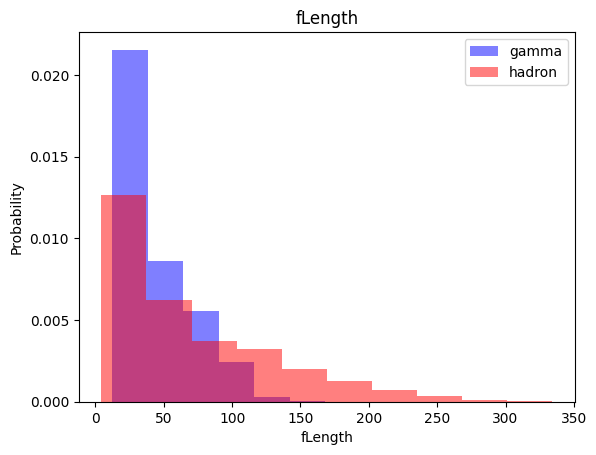

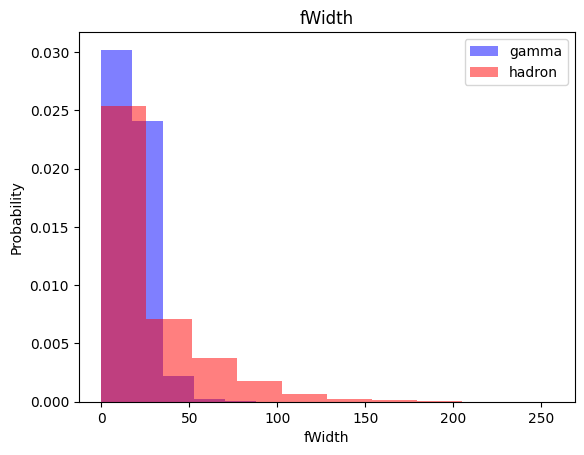

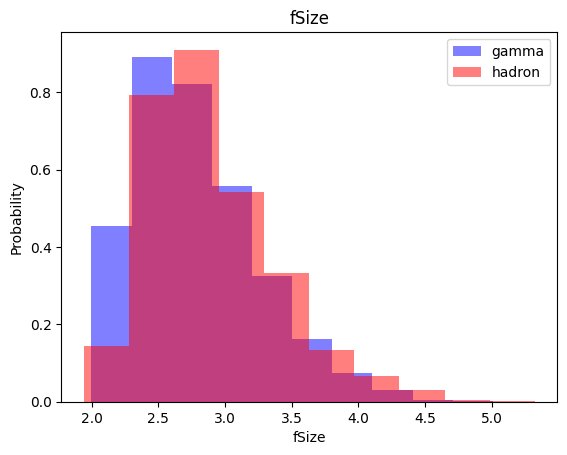

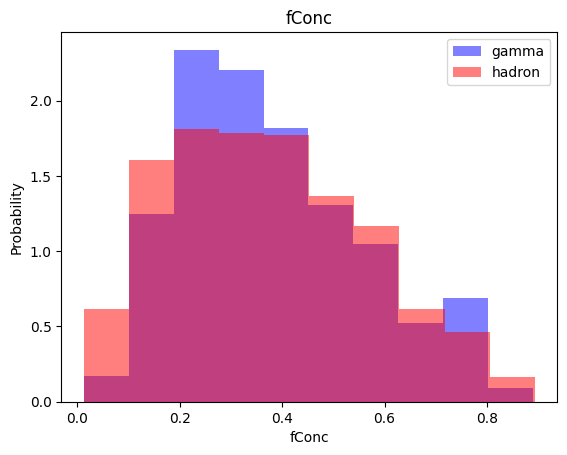

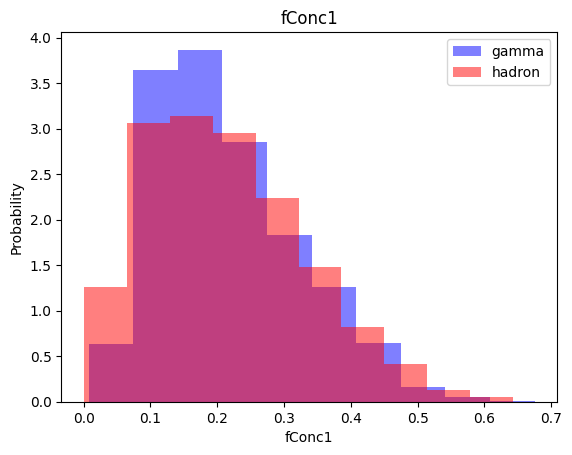

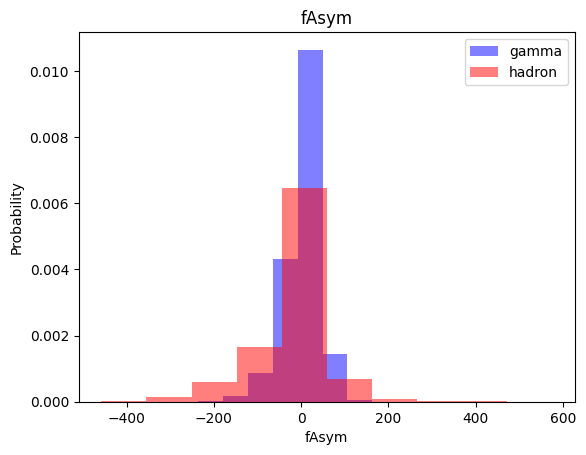

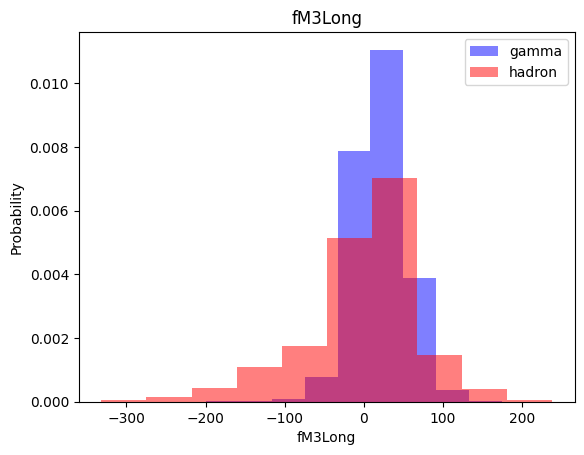

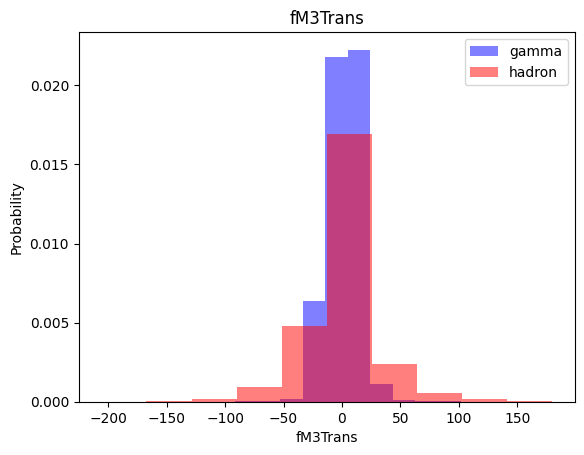

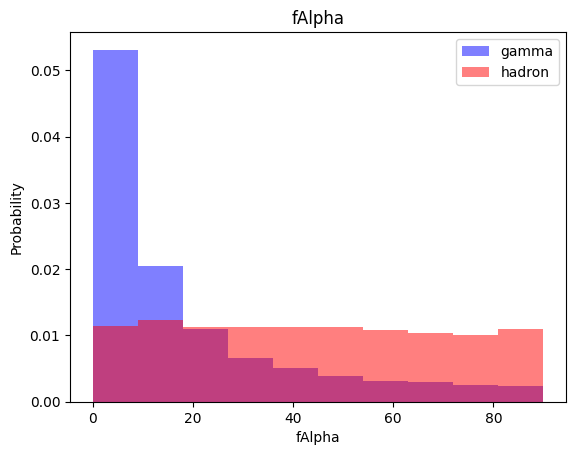

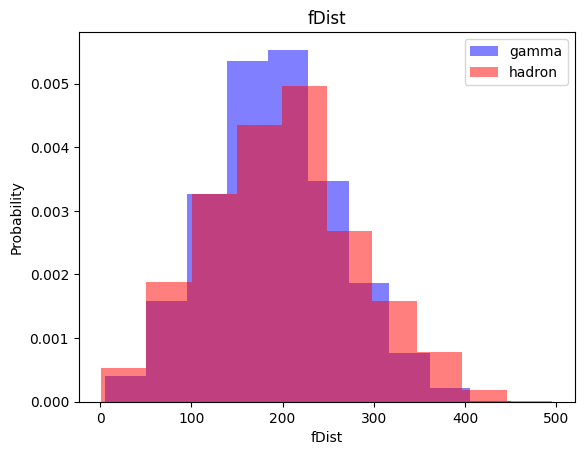

In [6]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==1][label], color='blue', label='gamma', alpha=0.5, density=True)
    plt.hist(df[df["class"]==0][label], color='red', label='hadron', alpha=0.5, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

# Train, validation, test datasets

In [7]:
train_arr, valid_arr, test_arr = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

train, valid, test = (pd.DataFrame(arr, columns=df.columns) for arr in [train_arr, valid_arr, test_arr])

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [8]:
def scale_dataset(dataframe, oversample=False):
    x = dataframe[dataframe.columns[:-1]].values
    y = dataframe[dataframe.columns[-1]].values
    
    scaler = StandardScaler()
    x = scaler.fit_transform(x)
    
    # split the sample evenly when one side of data is covering more
    if oversample:
        ros = RandomOverSampler()
        x, y = ros.fit_resample(x, y)
    
    data = np.hstack((x, np.reshape(y, (-1, 1))))
    
    return data, x, y

In [9]:
print(len(train[train["class"]==1]))
print(len(train[train["class"]==0]))

7431
3981


In [10]:
train_arr, x_train, y_train = scale_dataset(train, oversample=True)
valid_arr, x_valid, y_valid = scale_dataset(valid, oversample=False)
test_arr, x_test, y_test = scale_dataset(test, oversample=False)

In [11]:
sum(y_train == 1)

7431

In [12]:
sum(y_train == 0)

7431

# K-nearest neighbours

<img src="./images/knn.png" alt="knn graph" style="height: 200px; width: auto;" />

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
y_predict = knn_model.predict(x_test)

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1336
           1       0.86      0.86      0.86      2468

    accuracy                           0.81      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.81      0.81      0.81      3804



See more details about precision and recall [here](https://en.wikipedia.org/wiki/Precision_and_recall)

# Naive Bayes

<img src="./images/naivebayes.webp" alt="naive bayes" style="height: 200px; width: auto;" />

In [16]:
from sklearn.naive_bayes import GaussianNB

In [17]:
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [18]:
y_predict = nb_model.predict(x_test)
 
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.67      0.40      0.50      1336
           1       0.73      0.89      0.81      2468

    accuracy                           0.72      3804
   macro avg       0.70      0.65      0.65      3804
weighted avg       0.71      0.72      0.70      3804



# Logistic Regression

<img src="images/logistic-regression.png" alt="Logistic regression graph" style="height: 200px; width: auto;" />

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lg_model = LogisticRegression()
lg_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_predict = lg_model.predict(x_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.68      0.72      0.70      1336
           1       0.84      0.82      0.83      2468

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.77      3804
weighted avg       0.79      0.78      0.78      3804



# Support Vector Machines

<img src="images/svm.png" alt="support vector machines" style="height: 200px; width: auto;" />

In [22]:
from sklearn.svm import SVC

In [23]:
svm_model = SVC()
svm_model = svm_model.fit(x_train, y_train)

In [24]:
y_predict = svm_model.predict(x_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1336
           1       0.89      0.91      0.90      2468

    accuracy                           0.87      3804
   macro avg       0.86      0.86      0.86      3804
weighted avg       0.87      0.87      0.87      3804



# Neural Network

<img src="images/nn.jpeg" alt="Neural Network" style="height: 200px; width: auto;" />

In [25]:
import tensorflow as tf

In [26]:
nn_model = tf.keras.Sequential()

nn_model.add(tf.keras.Input(shape=(10,)))
nn_model.add(tf.keras.layers.Dense(units=32, activation='relu'))
nn_model.add(tf.keras.layers.Dense(units=32, activation='relu'))
nn_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [27]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_accuracy(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [32]:
history = nn_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_valid, y_valid))

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.8796 - loss: 0.2751 - val_accuracy: 0.8546 - val_loss: 0.3543
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - accuracy: 0.8787 - loss: 0.2747 - val_accuracy: 0.8475 - val_loss: 0.3707
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8777 - loss: 0.2736 - val_accuracy: 0.8488 - val_loss: 0.3754
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.8786 - loss: 0.2729 - val_accuracy: 0.8591 - val_loss: 0.3461
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - accuracy: 0.8785 - loss: 0.2721 - val_accuracy: 0.8536 - val_loss: 0.3551
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - accuracy: 0.8806 - loss: 0.2707 - val_accuracy: 0.8460 - val_loss: 0.3769
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.8795 - loss: 0.2715 - val_accuracy: 0.8575 - val_loss: 0.3579
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8799 - loss: 0

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - accuracy: 0.8985 - loss: 0.2341 - val_accuracy: 0.8473 - val_loss: 0.3970
Epoch 100/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - accuracy: 0.9003 - loss: 0.2334 - val_accuracy: 0.8454 - val_loss: 0.3972


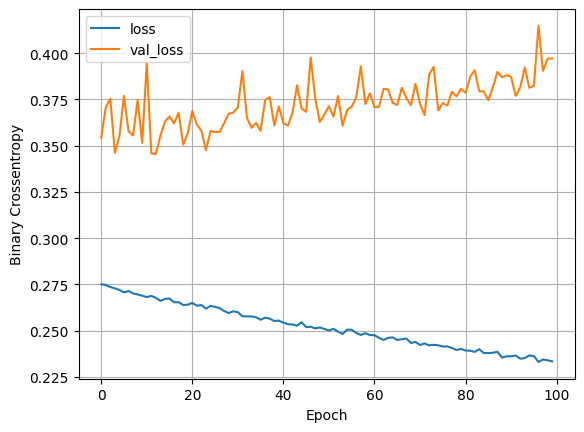

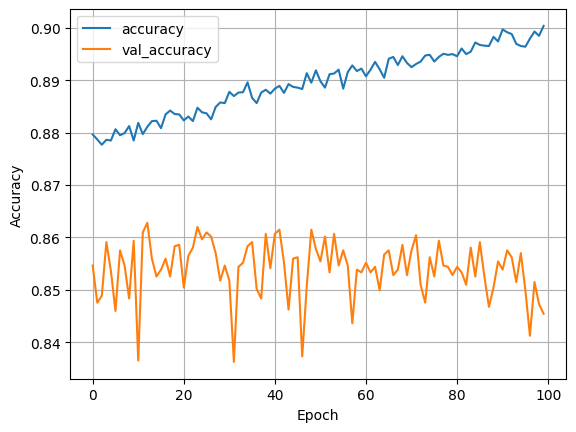

In [33]:
plot_loss(history)
plot_accuracy(history)

In [34]:
y_output = nn_model.predict(x_test)
y_predict = (y_output > 0.5).astype(int)
print(classification_report(y_test, y_predict))

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step
              precision    recall  f1-score   support

           0       0.77      0.82      0.80      1336
           1       0.90      0.87      0.89      2468

    accuracy                           0.85      3804
   macro avg       0.84      0.85      0.84      3804
weighted avg       0.86      0.85      0.86      3804

